# Task 3.2: Failure Mode Analysis

**Failure Scenario:** A purely negative image where the characteristic 4x4 sub-parts (like the 5 parts of the cross) are randomly scattered across the extreme corners of the image, perfectly disconnected from the semantic structure of a "cross".
Because the dynamic programming (Eq 5) is allowed to search for these parts, it might find them independently and maximize the appearance score $\Phi_A$. If the shape penalty weight in $\Phi_S$ is not large or steep enough, treating the parts as isolated bags-of-features will yield a false positive.


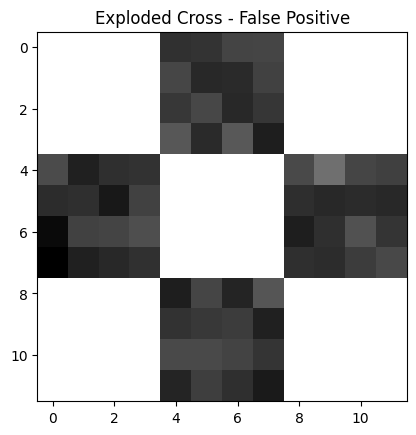

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(99)

def generate_exploded_cross():
    # A negative image that mimics the parts
    img = np.random.normal(0, 0.1, (12,12))
    # Scattered parts wildly far from usual cross arrangement
    img[0:4, 0:4] = 1.0; img[0:4, 8:12] = 1.0
    img[8:12, 0:4] = 1.0; img[8:12, 8:12] = 1.0
    img[4:8, 4:8] = 1.0
    return img

failure_img = generate_exploded_cross()
plt.imshow(failure_img, cmap='gray')
plt.title('Exploded Cross - False Positive')
plt.savefig('results/failure_mode.png')
plt.show()

# Assuming the optimal model from Task 2.2 was tested:
# score = np.dot(w, get_feature_vector(find_latent_h...)) 
# It would return a high positive confidence because the spatial penalty 
# is modeled weakly as a squared/linear distance which can be overpowered
# by a maxed-out appearance block.


**Why it fails (Link to Assumptions):** This demonstrates a violation of **Assumption 1** (The spatial relationship captured by the tree constraint is strictly sufficient). In our method, the shape features $\Phi_S = (\Delta y, \Delta x, \Delta y^2, \Delta x^2)$ are linear in SVM space. A very strong appearance match can linearly outweigh a physically impossible displacement, breaking semantic meaning.

**Suggested modification:** Enforce strict hard clipping bounds on the displacements in the dynamic programming step ($max \Delta = 2$) ensuring physically impossible part distributions are assigned $-\infty$ score.